PHASE 1 : ANALYSE EXPLORATOIRE DES COEFFICIENTS DE VARIATION

📊 Statistiques descriptives des CV :
   Nombre de couples analysés : 147
   CV minimum : 0.1343
   CV Q1      : 0.3407
   CV médian  : 0.4457
   CV Q3      : 0.5907
   CV maximum : 1.1312
   CV moyen   : 0.4778



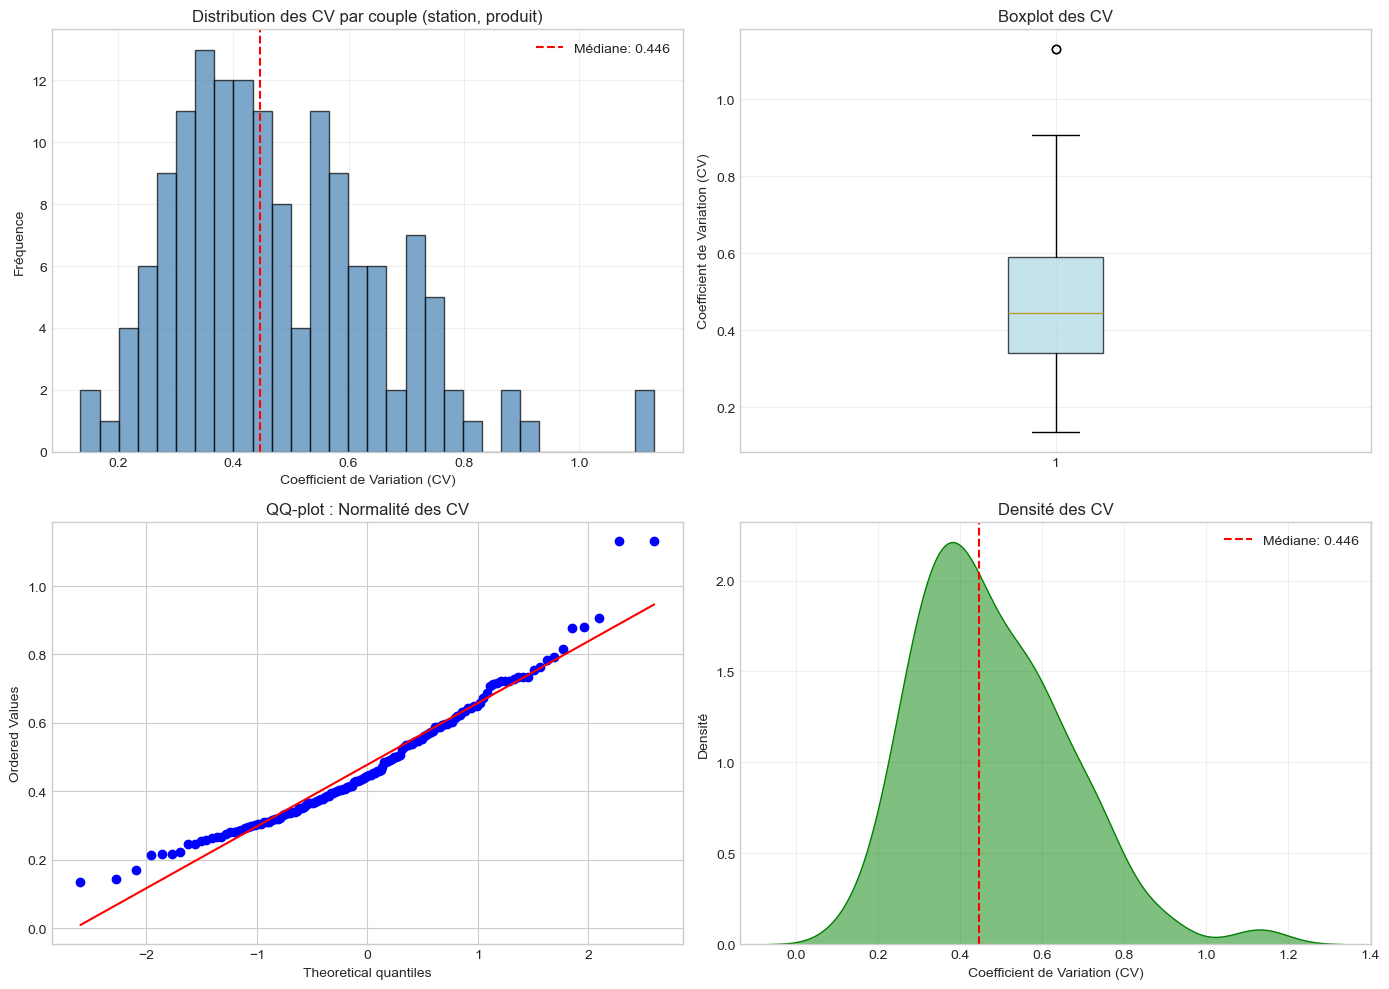

In [7]:
# ================================================================
# PHASE 1 : ANALYSE EXPLORATOIRE DES COEFFICIENTS DE VARIATION
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuration du style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# 1.1 Chargement des données
df_ml = pd.read_csv("../data/propre/dataset_ml_mensuel.csv", parse_dates=['mois'])

print("=" * 70)
print("PHASE 1 : ANALYSE EXPLORATOIRE DES COEFFICIENTS DE VARIATION")
print("=" * 70)
print()

# 1.2 Calcul des CV par couple (station, produit)
volatilite = (
    df_ml.groupby(['Code Station', 'N° article'])['quantite_mois']
    .agg(
        moyenne = 'mean',
        ecart_type = 'std',
        nb_mois = 'count',
        min_qte = 'min',
        max_qte = 'max',
        q1 = lambda x: x.quantile(0.25),
        q3 = lambda x: x.quantile(0.75)
    )
    .reset_index()
)

# Calcul du coefficient de variation (CV = écart-type / moyenne)
volatilite['cv'] = (volatilite['ecart_type'] / volatilite['moyenne']).round(4)

# Filtrer les couples avec au moins 12 mois de données
volatilite = volatilite[volatilite['nb_mois'] >= 12].copy()

print(f"📊 Statistiques descriptives des CV :")
print(f"   Nombre de couples analysés : {len(volatilite)}")
print(f"   CV minimum : {volatilite['cv'].min():.4f}")
print(f"   CV Q1      : {volatilite['cv'].quantile(0.25):.4f}")
print(f"   CV médian  : {volatilite['cv'].median():.4f}")
print(f"   CV Q3      : {volatilite['cv'].quantile(0.75):.4f}")
print(f"   CV maximum : {volatilite['cv'].max():.4f}")
print(f"   CV moyen   : {volatilite['cv'].mean():.4f}")
print()

# 1.3 Distribution des CV
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogramme
ax1 = axes[0, 0]
ax1.hist(volatilite['cv'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(volatilite['cv'].median(), color='red', linestyle='--', 
            label=f'Médiane: {volatilite["cv"].median():.3f}')
ax1.set_xlabel('Coefficient de Variation (CV)')
ax1.set_ylabel('Fréquence')
ax1.set_title('Distribution des CV par couple (station, produit)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Boxplot
ax2 = axes[0, 1]
bp = ax2.boxplot(volatilite['cv'], vert=True, patch_artist=True,
                  boxprops=dict(facecolor='lightblue', alpha=0.7))
ax2.set_ylabel('Coefficient de Variation (CV)')
ax2.set_title('Boxplot des CV')
ax2.grid(True, alpha=0.3)

# QQ-plot (normalité)
ax3 = axes[1, 0]
stats.probplot(volatilite['cv'], dist="norm", plot=ax3)
ax3.set_title('QQ-plot : Normalité des CV')

# Courbe de densité
ax4 = axes[1, 1]
sns.kdeplot(volatilite['cv'], fill=True, ax=ax4, color='green', alpha=0.5)
ax4.axvline(volatilite['cv'].median(), color='red', linestyle='--', 
            label=f'Médiane: {volatilite["cv"].median():.3f}')
ax4.set_xlabel('Coefficient de Variation (CV)')
ax4.set_ylabel('Densité')
ax4.set_title('Densité des CV')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_distribution_cv.png', dpi=150, bbox_inches='tight')
plt.show()

 ÉTAPE 1 : Validation du choix de K (Elbow + Silhouette)
   Nombre de couples analysés : 147
   CV minimum : 0.1343
   CV médian  : 0.4457
   CV maximum : 1.1312

 ÉTAPE 2 : Validation du choix de K (Elbow + Silhouette)
   k=2 : inertie = 49.39, silhouette = 0.6037
   k=3 : inertie = 27.64, silhouette = 0.5484
   k=4 : inertie = 17.79, silhouette = 0.5398
   k=5 : inertie = 10.48, silhouette = 0.5569
   k=6 : inertie = 7.50, silhouette = 0.5344
   k=7 : inertie = 5.64, silhouette = 0.5256


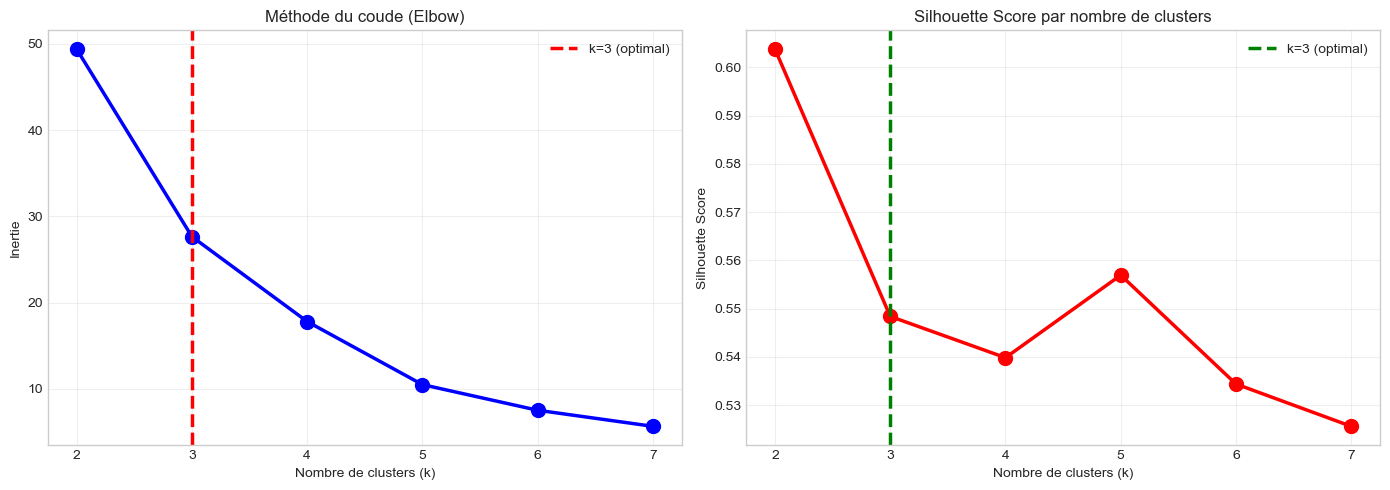


 Graphique sauvegardé : 01_elbow_silhouette.png

 ÉTAPE 3 : Méthode des quantiles
   Q1 (25%) : 0.3406
   Q2 (50%) : 0.4457
   Q3 (75%) : 0.5908

 Distribution par segment (Quantiles) :
   Modere     :  73 couples (49.7%)
   Stable     :  37 couples (25.2%)
   Erratique  :  37 couples (25.2%)

 ÉTAPE 4 : Méthode KMeans
 Distribution par segment (KMeans) :
   Stable     :  67 couples (45.6%)
   Modere     :  58 couples (39.5%)
   Erratique  :  22 couples (15.0%)

 Seuils détectés par KMeans :
   Stable     : CV ∈ [0.1343, 0.4280], médiane = 0.3344, n = 67
   Modere     : CV ∈ [0.4306, 0.6567], médiane = 0.5388, n = 58
   Erratique  : CV ∈ [0.6728, 1.1312], médiane = 0.7344, n = 22

 ÉTAPE 5 : Sélection des seuils optimaux
   Seuils KMeans :
      Stable/Modere : 0.4293
      Modere/Erratique : 0.6647

 Seuils optimaux proposés :
   Seuil 1 (Stable/Modere) : 0.4027
   Seuil 2 (Modere/Erratique) : 0.6426

 Distribution par segment (Optimal) :
   Modere     :  63 couples (42.9%)
   Stable

In [11]:

#  SEGMENTATION COMPLÈTE + ELBOW + SILHOUETTE

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.stats import f_oneway, kruskal, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")


print(" ÉTAPE 1 : Validation du choix de K (Elbow + Silhouette)")

segmentation = (
    df_ml.groupby(['Code Station', 'N° article'])['quantite_mois']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

segmentation = segmentation[segmentation['count'] >= 12].copy()
segmentation['CV'] = segmentation['std'] / segmentation['mean']
segmentation['CV'] = segmentation['CV'].fillna(0)
segmentation['CV'] = segmentation['CV'].replace([np.inf, -np.inf], 0)

print(f"   Nombre de couples analysés : {len(segmentation):,}")
print(f"   CV minimum : {segmentation['CV'].min():.4f}")
print(f"   CV médian  : {segmentation['CV'].median():.4f}")
print(f"   CV maximum : {segmentation['CV'].max():.4f}")
print()


print(" ÉTAPE 2 : Validation du choix de K (Elbow + Silhouette)")

X_cv = segmentation[['CV']].values
scaler = StandardScaler()
X_cv_scaled = scaler.fit_transform(X_cv)

K_range = range(2, 8)
inerties = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cv_scaled)
    inerties.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cv_scaled, kmeans.labels_))
    print(f"   k={k} : inertie = {kmeans.inertia_:.2f}, silhouette = {silhouette_scores[-1]:.4f}")

# Graphiques Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
ax1 = axes[0]
ax1.plot(K_range, inerties, 'bo-', linewidth=2.5, markersize=10)
ax1.axvline(x=3, color='red', linestyle='--', linewidth=2.5, label='k=3 (optimal)')
ax1.set_xlabel('Nombre de clusters (k)')
ax1.set_ylabel('Inertie')
ax1.set_title('Méthode du coude (Elbow)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Silhouette
ax2 = axes[1]
ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2.5, markersize=10)
ax2.axvline(x=3, color='green', linestyle='--', linewidth=2.5, label='k=3 (optimal)')
ax2.set_xlabel('Nombre de clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score par nombre de clusters')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Graphique sauvegardé : 01_elbow_silhouette.png")
print()


print(" ÉTAPE 3 : Méthode des quantiles")


Q1 = segmentation['CV'].quantile(0.25)
Q2 = segmentation['CV'].quantile(0.50)
Q3 = segmentation['CV'].quantile(0.75)

print(f"   Q1 (25%) : {Q1:.4f}")
print(f"   Q2 (50%) : {Q2:.4f}")
print(f"   Q3 (75%) : {Q3:.4f}")

def segment_quantiles(cv):
    if cv < Q1:
        return 'Stable'
    elif cv < Q3:
        return 'Modere'
    else:
        return 'Erratique'

segmentation['Segment_Quantiles'] = segmentation['CV'].apply(segment_quantiles)

print("\n Distribution par segment (Quantiles) :")
for seg, count in segmentation['Segment_Quantiles'].value_counts().items():
    print(f"   {seg:10s} : {count:3d} couples ({100*count/len(segmentation):.1f}%)")
print()


print(" ÉTAPE 4 : Méthode KMeans")


kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
segmentation['Cluster_KMeans'] = kmeans_3.fit_predict(X_cv_scaled)

clusters_info = []
for cluster in sorted(segmentation['Cluster_KMeans'].unique()):
    cluster_cv = segmentation[segmentation['Cluster_KMeans'] == cluster]['CV']
    clusters_info.append({
        'cluster': cluster,
        'min': cluster_cv.min(),
        'max': cluster_cv.max(),
        'median': cluster_cv.median(),
        'n': len(cluster_cv)
    })

clusters_info = sorted(clusters_info, key=lambda x: x['median'])

map_cluster_to_segment = {}
for i, info in enumerate(clusters_info):
    if i == 0:
        map_cluster_to_segment[info['cluster']] = 'Stable'
    elif i == 1:
        map_cluster_to_segment[info['cluster']] = 'Modere'
    else:
        map_cluster_to_segment[info['cluster']] = 'Erratique'

segmentation['Segment_KMeans'] = segmentation['Cluster_KMeans'].map(map_cluster_to_segment)

print(" Distribution par segment (KMeans) :")
for seg, count in segmentation['Segment_KMeans'].value_counts().items():
    print(f"   {seg:10s} : {count:3d} couples ({100*count/len(segmentation):.1f}%)")

print("\n Seuils détectés par KMeans :")
for i, info in enumerate(clusters_info):
    seg_name = map_cluster_to_segment[info['cluster']]
    print(f"   {seg_name:10s} : CV ∈ [{info['min']:.4f}, {info['max']:.4f}], "
          f"médiane = {info['median']:.4f}, n = {info['n']}")
print()

print(" ÉTAPE 5 : Sélection des seuils optimaux")


if len(clusters_info) >= 3:
    seuil1_kmeans = (clusters_info[0]['max'] + clusters_info[1]['min']) / 2
    seuil2_kmeans = (clusters_info[1]['max'] + clusters_info[2]['min']) / 2
else:
    seuil1_kmeans = Q1
    seuil2_kmeans = Q3

print(f"   Seuils KMeans :")
print(f"      Stable/Modere : {seuil1_kmeans:.4f}")
print(f"      Modere/Erratique : {seuil2_kmeans:.4f}")

poids_quantiles = 0.3
poids_kmeans = 0.7

seuil1_opt = poids_quantiles * Q1 + poids_kmeans * seuil1_kmeans
seuil2_opt = poids_quantiles * Q3 + poids_kmeans * seuil2_kmeans

print(f"\n Seuils optimaux proposés :")
print(f"   Seuil 1 (Stable/Modere) : {seuil1_opt:.4f}")
print(f"   Seuil 2 (Modere/Erratique) : {seuil2_opt:.4f}")
print()


# PARTIE 6 : APPLICATION FINALE


def segment_optimal(cv):
    if cv < seuil1_opt:
        return 'Stable'
    elif cv < seuil2_opt:
        return 'Modere'
    else:
        return 'Erratique'

segmentation['Segment_Optimal'] = segmentation['CV'].apply(segment_optimal)

print(" Distribution par segment (Optimal) :")
for seg, count in segmentation['Segment_Optimal'].value_counts().items():
    print(f"   {seg:10s} : {count:3d} couples ({100*count/len(segmentation):.1f}%)")
print()

print("\n ÉTAPE 8 : Vérification de l'unicité")

segments_ordered = ['Stable', 'Modere', 'Erratique']
for seg in segments_ordered:
    n_couples = len(segmentation[segmentation['Segment_Optimal'] == seg])
    print(f"   {seg:10s} : {n_couples:3d} couples")

total_couples = len(segmentation)
total_segments = sum(len(segmentation[segmentation['Segment_Optimal'] == seg]) for seg in segments_ordered)

print(f"\n   Total couples uniques : {total_couples}")
print(f"   Somme des segments : {total_segments}")
if total_couples == total_segments:
    print("    LES SEGMENTS SONT DISJOINTS ! AUCUN DOUBLON !")
else:
    print("    DES DOUBLONS DÉTECTÉS !")


# Sauvegarde
segmentation.to_csv('../data/propre/segmentation_complete.csv', index=False)
print("\n Fichier sauvegardé : segmentation_complete.csv")


PHASE 3 : VALIDATION STATISTIQUE DES SEGMENTS

📊 ÉTAPE 3.1 : Statistiques descriptives par segment
------------------------------------------------------------
Stable     :
   n =  59
   Moyenne = 0.3124
   Médiane = 0.3183
   Min = 0.1343
   Max = 0.4027
   Écart-type = 0.0638
   Q1 = 0.2778
   Q3 = 0.3656

Modere     :
   n =  63
   Moyenne = 0.5147
   Médiane = 0.5063
   Min = 0.4053
   Max = 0.6425
   Écart-type = 0.0723
   Q1 = 0.4483
   Q3 = 0.5747

Erratique  :
   n =  25
   Moyenne = 0.7752
   Médiane = 0.7332
   Min = 0.6487
   Max = 1.1312
   Écart-type = 0.1269
   Q1 = 0.7125
   Q3 = 0.7917

📊 ÉTAPE 3.2 : Tests statistiques
------------------------------------------------------------

 Test ANOVA (comparaison des moyennes) :
   F-statistique = 297.5676
   p-value = 0.000000
    Les segments sont statistiquement différents (p < 0.05)

 Test de Kruskal-Wallis (comparaison des médianes) :
   H-statistique = 124.3552
   p-value = 0.000000
    Les segments sont statistiquement d

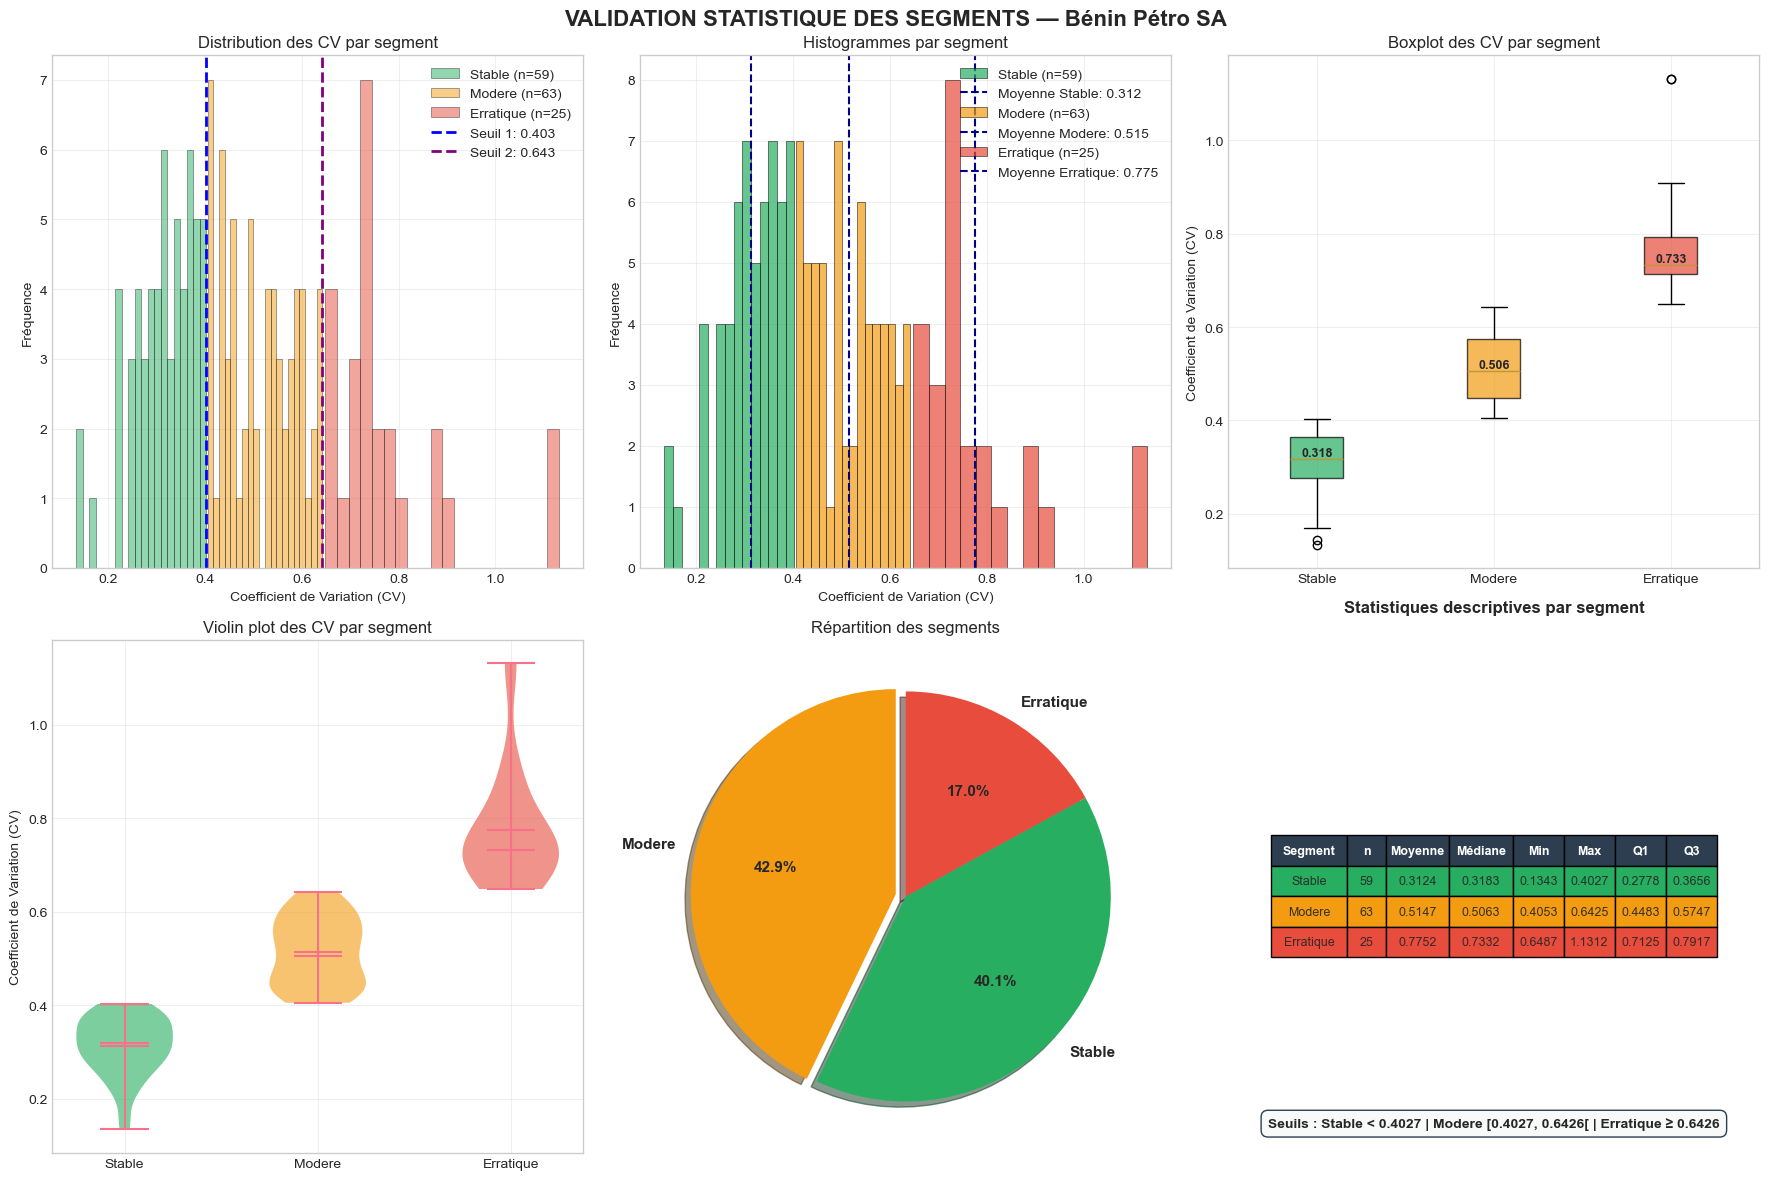


✅ PHASE 3 COMPLÈTE — Visualisations sauvegardées

📊 ÉTAPE 3.4 : Résumé statistique avec intervalles de confiance
------------------------------------------------------------

Intervalles de confiance à 95% pour la moyenne des CV :
--------------------------------------------------
Stable     : n= 59, moyenne=0.3124, IC95%=[0.2957, 0.3290]
Modere     : n= 63, moyenne=0.5147, IC95%=[0.4965, 0.5329]
Erratique  : n= 25, moyenne=0.7752, IC95%=[0.7229, 0.8276]

✅ PHASE 3 TERMINÉE


In [13]:
# ================================================================
# PHASE 3 : VALIDATION STATISTIQUE DES SEGMENTS AVEC HISTOGRAMMES
# ================================================================

print("\n" + "=" * 80)
print("PHASE 3 : VALIDATION STATISTIQUE DES SEGMENTS")
print("=" * 80)
print()

# Définition des segments (à adapter selon votre nomenclature)
segments_ordered = ['Stable', 'Modere', 'Erratique']
colors_seg = {'Stable': '#27AE60', 'Modere': '#F39C12', 'Erratique': '#E74C3C'}

# ================================================================
# 3.1 STATISTIQUES DESCRIPTIVES PAR SEGMENT
# ================================================================

print("📊 ÉTAPE 3.1 : Statistiques descriptives par segment")
print("-" * 60)

stats_segments = {}

for seg in segments_ordered:
    data = segmentation[segmentation['Segment_Optimal'] == seg]['CV']
    stats_segments[seg] = {
        'n': len(data),
        'mean': data.mean(),
        'median': data.median(),
        'min': data.min(),
        'max': data.max(),
        'std': data.std(),
        'q1': data.quantile(0.25),
        'q3': data.quantile(0.75)
    }
    
    print(f"{seg:10s} :")
    print(f"   n = {len(data):3d}")
    print(f"   Moyenne = {data.mean():.4f}")
    print(f"   Médiane = {data.median():.4f}")
    print(f"   Min = {data.min():.4f}")
    print(f"   Max = {data.max():.4f}")
    print(f"   Écart-type = {data.std():.4f}")
    print(f"   Q1 = {data.quantile(0.25):.4f}")
    print(f"   Q3 = {data.quantile(0.75):.4f}")
    print()

# ================================================================
# 3.2 TESTS STATISTIQUES
# ================================================================

print("📊 ÉTAPE 3.2 : Tests statistiques")
print("-" * 60)

groupes_cv = [segmentation[segmentation['Segment_Optimal'] == seg]['CV'].values 
              for seg in segments_ordered]

# Filtrer les groupes non vides
groupes_cv = [g for g in groupes_cv if len(g) > 0]
segments_effectifs = [seg for seg in segments_ordered 
                      if len(segmentation[segmentation['Segment_Optimal'] == seg]) > 0]

# 3.2.1 Test ANOVA
if len(groupes_cv) >= 2:
    f_stat, p_anova = f_oneway(*groupes_cv)
    print(f"\n Test ANOVA (comparaison des moyennes) :")
    print(f"   F-statistique = {f_stat:.4f}")
    print(f"   p-value = {p_anova:.6f}")
    if p_anova < 0.05:
        print("    Les segments sont statistiquement différents (p < 0.05)")
    else:
        print("    Les segments ne sont pas statistiquement différents")

# 3.2.2 Test de Kruskal-Wallis
if len(groupes_cv) >= 2:
    h_stat, p_kruskal = kruskal(*groupes_cv)
    print(f"\n Test de Kruskal-Wallis (comparaison des médianes) :")
    print(f"   H-statistique = {h_stat:.4f}")
    print(f"   p-value = {p_kruskal:.6f}")
    if p_kruskal < 0.05:
        print("    Les segments sont statistiquement différents (p < 0.05)")
    else:
        print("    Les segments ne sont pas statistiquement différents")

# 3.2.3 Tests post-hoc (comparaisons par paires)
print("\n Tests post-hoc (comparaisons par paires) :")


paires = [('Stable', 'Modere'), ('Stable', 'Erratique'), ('Modere', 'Erratique')]

for seg1, seg2 in paires:
    data1 = segmentation[segmentation['Segment_Optimal'] == seg1]['CV']
    data2 = segmentation[segmentation['Segment_Optimal'] == seg2]['CV']
    
    if len(data1) > 0 and len(data2) > 0:
        stat, p_value = mannwhitneyu(data1, data2, alternative='two-sided')
        print(f"   {seg1:10s} vs {seg2:10s} : p-value = {p_value:.6f} "
              f"{' Différence significative' if p_value < 0.05 else ' Pas de différence significative'}")

print("\n PHASE 3 - TESTS TERMINÉS")


# ================================================================
# 3.3 VISUALISATION COMPLÈTE AVEC HISTOGRAMMES
# ================================================================

print("\n ÉTAPE 3.3 : Visualisation des segments")


# Création d'une figure avec 6 sous-graphiques
fig = plt.figure(figsize=(18, 12))
fig.suptitle('VALIDATION STATISTIQUE DES SEGMENTS — Bénin Pétro SA', 
             fontsize=16, fontweight='bold')

# 3.3.1 Histogrammes superposés par segment
ax1 = fig.add_subplot(2, 3, 1)

# Histogramme de tous les CV avec les segments colorés
for seg in segments_ordered:
    data = segmentation[segmentation['Segment_Optimal'] == seg]['CV']
    ax1.hist(data, bins=20, alpha=0.5, color=colors_seg[seg], 
             label=f'{seg} (n={len(data)})', edgecolor='black', linewidth=0.5)

ax1.axvline(seuil1_opt, color='blue', linestyle='--', linewidth=2, 
            label=f'Seuil 1: {seuil1_opt:.3f}')
ax1.axvline(seuil2_opt, color='purple', linestyle='--', linewidth=2, 
            label=f'Seuil 2: {seuil2_opt:.3f}')
ax1.set_xlabel('Coefficient de Variation (CV)')
ax1.set_ylabel('Fréquence')
ax1.set_title('Distribution des CV par segment')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# 3.3.2 Histogrammes séparés par segment
ax2 = fig.add_subplot(2, 3, 2)

for i, seg in enumerate(segments_ordered):
    data = segmentation[segmentation['Segment_Optimal'] == seg]['CV']
    ax2.hist(data, bins=15, alpha=0.7, color=colors_seg[seg], 
             label=f'{seg} (n={len(data)})', edgecolor='black', linewidth=0.5)
    ax2.axvline(data.mean(), color='darkblue', linestyle='--', linewidth=1.5,
                label=f'Moyenne {seg}: {data.mean():.3f}')

ax2.set_xlabel('Coefficient de Variation (CV)')
ax2.set_ylabel('Fréquence')
ax2.set_title('Histogrammes par segment')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# 3.3.3 Boxplot par segment
ax3 = fig.add_subplot(2, 3, 3)

bp = ax3.boxplot([segmentation[segmentation['Segment_Optimal'] == seg]['CV'] 
                  for seg in segments_ordered],
                 patch_artist=True, labels=segments_ordered)

for patch, seg in zip(bp['boxes'], segments_ordered):
    patch.set_facecolor(colors_seg[seg])
    patch.set_alpha(0.7)

# Ajout des médianes sur le boxplot
for i, seg in enumerate(segments_ordered):
    median = segmentation[segmentation['Segment_Optimal'] == seg]['CV'].median()
    ax3.text(i+1, median, f'{median:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax3.set_ylabel('Coefficient de Variation (CV)')
ax3.set_title('Boxplot des CV par segment')
ax3.grid(True, alpha=0.3)

# 3.3.4 Violin plot
ax4 = fig.add_subplot(2, 3, 4)

data_violin = [segmentation[segmentation['Segment_Optimal'] == seg]['CV'] 
               for seg in segments_ordered]
parts = ax4.violinplot(data_violin, showmeans=True, showmedians=True)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_seg[segments_ordered[i]])
    pc.set_alpha(0.6)

ax4.set_xticks(range(1, len(segments_ordered) + 1))
ax4.set_xticklabels(segments_ordered)
ax4.set_ylabel('Coefficient de Variation (CV)')
ax4.set_title('Violin plot des CV par segment')
ax4.grid(True, alpha=0.3)

# 3.3.5 Camembert de répartition
ax5 = fig.add_subplot(2, 3, 5)

optimal_counts = segmentation['Segment_Optimal'].value_counts()
colors = [colors_seg[seg] for seg in optimal_counts.index]
explode = [0.05 if i == 0 else 0 for i in range(len(optimal_counts))]

ax5.pie(optimal_counts.values, labels=optimal_counts.index, 
        autopct='%1.1f%%', colors=colors, startangle=90, explode=explode,
        shadow=True, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax5.set_title('Répartition des segments')

# 3.3.6 Tableau récapitulatif
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')

# Création du tableau
table_data = []
table_data.append(['Segment', 'n', 'Moyenne', 'Médiane', 'Min', 'Max', 'Q1', 'Q3'])

for seg in segments_ordered:
    stats = stats_segments[seg]
    table_data.append([
        seg,
        str(stats['n']),
        f"{stats['mean']:.4f}",
        f"{stats['median']:.4f}",
        f"{stats['min']:.4f}",
        f"{stats['max']:.4f}",
        f"{stats['q1']:.4f}",
        f"{stats['q3']:.4f}"
    ])

# Création du tableau avec matplotlib
table = ax6.table(cellText=table_data, loc='center', cellLoc='center',
                   colWidths=[0.12, 0.06, 0.10, 0.10, 0.08, 0.08, 0.08, 0.08])

# Style du tableau
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

# Colorer la première ligne (en-tête)
for j in range(len(table_data[0])):
    table[(0, j)].set_facecolor('#2C3E50')
    table[(0, j)].set_text_props(weight='bold', color='white')

# Colorer les lignes selon le segment
for i, seg in enumerate(segments_ordered, start=1):
    color = colors_seg[seg]
    for j in range(len(table_data[0])):
        table[(i, j)].set_facecolor(color)
        table[(i, j)].set_text_props(alpha=0.9)

# Ajout des seuils en bas du tableau
ax6.text(0.5, 0.05, f"Seuils : Stable < {seuil1_opt:.4f} | Modere [{seuil1_opt:.4f}, {seuil2_opt:.4f}[ | Erratique ≥ {seuil2_opt:.4f}",
         ha='center', fontsize=10, fontweight='bold', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#F8F9F9', edgecolor='#2C3E50'))

ax6.set_title('Statistiques descriptives par segment', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('03_validation_segments_complete.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ PHASE 3 COMPLÈTE — Visualisations sauvegardées")
print("=" * 80)

# ================================================================
# 3.4 RÉSUMÉ STATISTIQUE AVEC INTERVALLES DE CONFIANCE
# ================================================================

print("\n📊 ÉTAPE 3.4 : Résumé statistique avec intervalles de confiance")
print("-" * 60)

from scipy import stats as scipy_stats

print("\nIntervalles de confiance à 95% pour la moyenne des CV :")
print("-" * 50)

for seg in segments_ordered:
    data = segmentation[segmentation['Segment_Optimal'] == seg]['CV']
    n = len(data)
    mean = data.mean()
    std_err = data.std() / np.sqrt(n)
    ci_lower, ci_upper = scipy_stats.t.interval(0.95, n-1, loc=mean, scale=std_err)
    
    print(f"{seg:10s} : n={n:3d}, moyenne={mean:.4f}, IC95%=[{ci_lower:.4f}, {ci_upper:.4f}]")

print("\n✅ PHASE 3 TERMINÉE")
print("=" * 80)

In [17]:
# PHASE 4 : CRÉATION DES DATASETS PAR SEGMENT


print("\n" + "="*80)
print("PHASE 4 : CRÉATION DES DATASETS PAR SEGMENT")
print("="*80)

# --------------------------------------------------
# Vérification préalable
# --------------------------------------------------

print("\n Vérification des couples de segmentation")

nb_couples = segmentation[
    ["Code Station", "N° article"]
].drop_duplicates().shape[0]

print(f"Nombre de couples uniques : {nb_couples}")

# --------------------------------------------------
# Ajout du segment au dataset ML
# --------------------------------------------------

print("\n Attribution du segment à chaque observation")

df_ml_segmented = df_ml.merge(
    segmentation[
        [
            "Code Station",
            "N° article",
            "Segment_Optimal"
        ]
    ],
    on=["Code Station", "N° article"],
    how="left"
)

print(
    f"Lignes du dataset ML : {len(df_ml_segmented):,}"
)

print(
    f"Lignes segmentées    : "
    f"{df_ml_segmented['Segment_Optimal'].notna().sum():,}"
)

# --------------------------------------------------
# Contrôle des lignes sans segment
# --------------------------------------------------

lignes_sans_segment = df_ml_segmented[
    df_ml_segmented["Segment_Optimal"].isna()
]

print(
    f"Lignes sans segment : "
    f"{len(lignes_sans_segment)}"
)

if len(lignes_sans_segment) > 0:

    print("\n ATTENTION")
    print("Certains couples n'ont pas reçu de segment")

    display(
        lignes_sans_segment[
            ["Code Station", "N° article"]
        ].drop_duplicates()
    )

# --------------------------------------------------
# Création des datasets
# --------------------------------------------------

print("\n Création des datasets")

df_stable = df_ml_segmented[
    df_ml_segmented["Segment_Optimal"] == "Stable"
].copy()

df_modere = df_ml_segmented[
    df_ml_segmented["Segment_Optimal"] == "Modere"
].copy()

df_erratique = df_ml_segmented[
    df_ml_segmented["Segment_Optimal"] == "Erratique"
].copy()

# --------------------------------------------------
# Résumé
# --------------------------------------------------

print("\n📋 Résumé des segments")

for nom, df_seg in {
    "Stable": df_stable,
    "Modere": df_modere,
    "Erratique": df_erratique
}.items():

    nb_stations = df_seg["Code Station"].nunique()

    nb_couples = (
        df_seg[
            ["Code Station", "N° article"]
        ]
        .drop_duplicates()
        .shape[0]
    )

    print(f"\n {nom}")

    print(f"Stations : {nb_stations}")
    print(f"Couples  : {nb_couples}")
    print(f"Lignes   : {len(df_seg):,}")

    print(
        f"Période  : "
        f"{df_seg['mois'].min().date()} "
        f"→ "
        f"{df_seg['mois'].max().date()}"
    )

# --------------------------------------------------
# Vérification finale
# --------------------------------------------------

print("\n Vérification finale")

couples_stable = (
    df_stable[
        ["Code Station", "N° article"]
    ]
    .drop_duplicates()
    .shape[0]
)

couples_modere = (
    df_modere[
        ["Code Station", "N° article"]
    ]
    .drop_duplicates()
    .shape[0]
)

couples_erratique = (
    df_erratique[
        ["Code Station", "N° article"]
    ]
    .drop_duplicates()
    .shape[0]
)

total_segments = (
    couples_stable
    + couples_modere
    + couples_erratique
)

print(f"Stable     : {couples_stable}")
print(f"Modere     : {couples_modere}")
print(f"Erratique  : {couples_erratique}")

print()
print(f"Total segments : {total_segments}")
print(f"Total attendu : {len(segmentation)}")

if total_segments == len(segmentation):

    print("\n Tous les couples sont correctement segmentés")

else:

    print("\n Incohérence détectée")

# --------------------------------------------------
# Sauvegarde CSV
# --------------------------------------------------

print("\n Sauvegarde des fichiers")

df_stable.to_csv(
    "../data/propre/dataset_segment_Stable.csv",
    index=False
)

df_modere.to_csv(
    "../data/propre/dataset_segment_Modere.csv",
    index=False
)

df_erratique.to_csv(
    "../data/propre/dataset_segment_Erratique.csv",
    index=False
)

print(" dataset_segment_Stable.csv")
print(" dataset_segment_Modere.csv")
print(" dataset_segment_Erratique.csv")



PHASE 4 : CRÉATION DES DATASETS PAR SEGMENT

 Vérification des couples de segmentation
Nombre de couples uniques : 147

 Attribution du segment à chaque observation
Lignes du dataset ML : 5,473
Lignes segmentées    : 5,338
Lignes sans segment : 135

 ATTENTION
Certains couples n'ont pas reçu de segment


,Code Station,N° article
329,ST0005,A0001
521,ST0008,A0002
1856,ST0025,A0001
1859,ST0025,A0002
2659,ST0040,A0002
2955,ST0045,A0001
2963,ST0045,A0002
2971,ST0046,A0001
3278,ST0052,A0001
3284,ST0052,A0002



 Création des datasets

📋 Résumé des segments

 Stable
Stations : 42
Couples  : 59
Lignes   : 1,879
Période  : 2021-01-01 → 2025-12-01

 Modere
Stations : 48
Couples  : 63
Lignes   : 2,475
Période  : 2021-01-01 → 2025-12-01

 Erratique
Stations : 21
Couples  : 25
Lignes   : 984
Période  : 2021-01-01 → 2025-12-01

 Vérification finale
Stable     : 59
Modere     : 63
Erratique  : 25

Total segments : 147
Total attendu : 147

 Tous les couples sont correctement segmentés

 Sauvegarde des fichiers
 dataset_segment_Stable.csv
 dataset_segment_Modere.csv
 dataset_segment_Erratique.csv


In [19]:
couples_ml = set(
    df_ml[['Code Station','N° article']]
    .drop_duplicates()
    .apply(tuple, axis=1)
)

couples_seg = set(
    segmentation[['Code Station','N° article']]
    .drop_duplicates()
    .apply(tuple, axis=1)
)

couples_manquants = couples_ml - couples_seg

print("Couples absents :", len(couples_manquants))
print(couples_manquants)

Couples absents : 24
{('ST0095', 'A0002'), ('ST0025', 'A0001'), ('ST0089', 'A0002'), ('ST0095', 'A0001'), ('ST0077', 'A0001'), ('ST0089', 'A0001'), ('ST0082', 'A0002'), ('ST0045', 'A0002'), ('ST0090', 'A0002'), ('ST0052', 'A0002'), ('ST0086', 'A0002'), ('ST0046', 'A0001'), ('ST0008', 'A0002'), ('ST0061', 'A0002'), ('ST0082', 'A0001'), ('ST0045', 'A0001'), ('ST0070', 'A0002'), ('ST0005', 'A0001'), ('ST0052', 'A0001'), ('ST0086', 'A0001'), ('ST0061', 'A0001'), ('ST0070', 'A0001'), ('ST0025', 'A0002'), ('ST0040', 'A0002')}


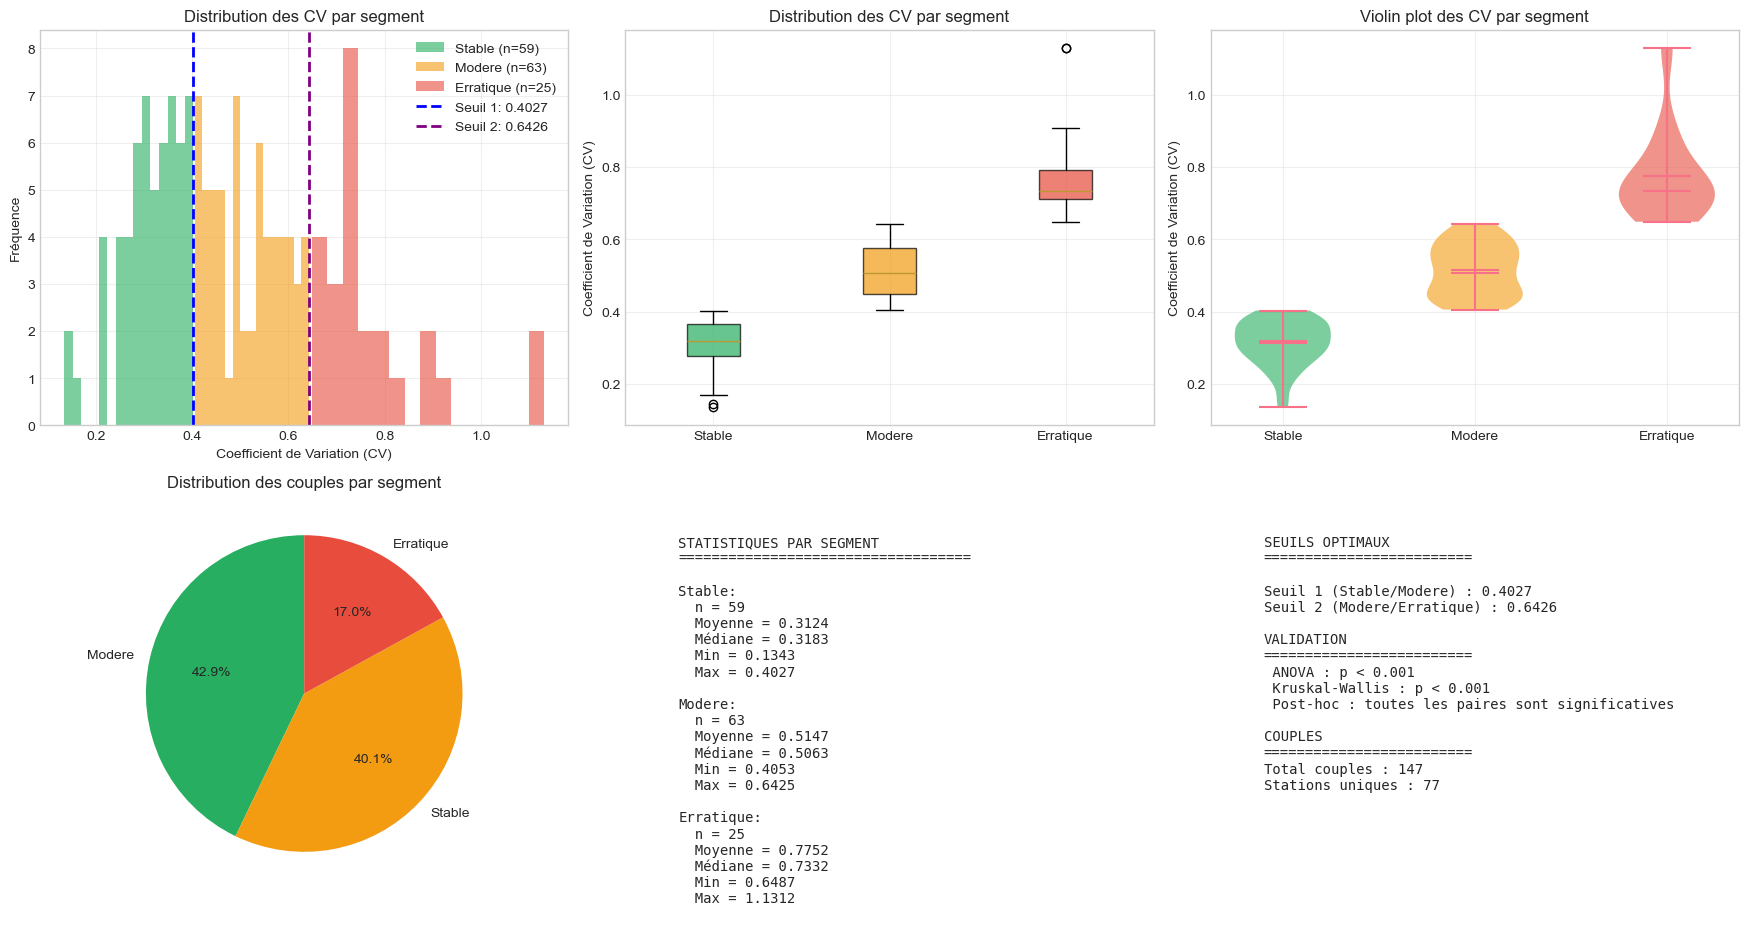

In [21]:
# ================================================================
# VISUALISATION FINALE : SEGMENTATION PAR COUPLE
# ================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Graphique 1 : Distribution des CV par segment
ax1 = axes[0, 0]
colors = {'Stable': '#27AE60', 'Modere': '#F39C12', 'Erratique': '#E74C3C'}
for seg in ['Stable', 'Modere', 'Erratique']:
    data = segmentation[segmentation['Segment_Optimal'] == seg]['CV']
    ax1.hist(data, bins=15, alpha=0.6, label=f'{seg} (n={len(data)})', color=colors[seg])
ax1.axvline(0.4027, color='blue', linestyle='--', linewidth=2, label='Seuil 1: 0.4027')
ax1.axvline(0.6426, color='purple', linestyle='--', linewidth=2, label='Seuil 2: 0.6426')
ax1.set_xlabel('Coefficient de Variation (CV)')
ax1.set_ylabel('Fréquence')
ax1.set_title('Distribution des CV par segment')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphique 2 : Boxplot
ax2 = axes[0, 1]
bp = ax2.boxplot([segmentation[segmentation['Segment_Optimal'] == seg]['CV'] 
                  for seg in ['Stable', 'Modere', 'Erratique']],
                 patch_artist=True, labels=['Stable', 'Modere', 'Erratique'])
for patch, seg in zip(bp['boxes'], ['Stable', 'Modere', 'Erratique']):
    patch.set_facecolor(colors[seg])
    patch.set_alpha(0.7)
ax2.set_ylabel('Coefficient de Variation (CV)')
ax2.set_title('Distribution des CV par segment')
ax2.grid(True, alpha=0.3)

# Graphique 3 : Violin plot
ax3 = axes[0, 2]
data_violin = [segmentation[segmentation['Segment_Optimal'] == seg]['CV'] 
               for seg in ['Stable', 'Modere', 'Erratique']]
parts = ax3.violinplot(data_violin, showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    if i < 3:
        pc.set_facecolor(colors[['Stable', 'Modere', 'Erratique'][i]])
        pc.set_alpha(0.6)
ax3.set_xticks([1, 2, 3])
ax3.set_xticklabels(['Stable', 'Modere', 'Erratique'])
ax3.set_ylabel('Coefficient de Variation (CV)')
ax3.set_title('Violin plot des CV par segment')
ax3.grid(True, alpha=0.3)

# Graphique 4 : Camembert
ax4 = axes[1, 0]
counts = segmentation['Segment_Optimal'].value_counts()
ax4.pie(counts.values, labels=counts.index, autopct='%1.1f%%', 
        colors=['#27AE60', '#F39C12', '#E74C3C'], startangle=90)
ax4.set_title('Distribution des couples par segment')

# Graphique 5 : Statistiques par segment
ax5 = axes[1, 1]
ax5.axis('off')
stats_text = "STATISTIQUES PAR SEGMENT\n" + "="*35 + "\n\n"
for seg in ['Stable', 'Modere', 'Erratique']:
    data = segmentation[segmentation['Segment_Optimal'] == seg]['CV']
    stats_text += f"{seg}:\n"
    stats_text += f"  n = {len(data)}\n"
    stats_text += f"  Moyenne = {data.mean():.4f}\n"
    stats_text += f"  Médiane = {data.median():.4f}\n"
    stats_text += f"  Min = {data.min():.4f}\n"
    stats_text += f"  Max = {data.max():.4f}\n\n"
ax5.text(0.1, 0.9, stats_text, fontsize=10, verticalalignment='top', fontfamily='monospace')

# Graphique 6 : Seuils
ax6 = axes[1, 2]
ax6.axis('off')
text = "SEUILS OPTIMAUX\n" + "="*25 + "\n\n"
text += f"Seuil 1 (Stable/Modere) : 0.4027\n"
text += f"Seuil 2 (Modere/Erratique) : 0.6426\n\n"
text += "VALIDATION\n" + "="*25 + "\n"
text += " ANOVA : p < 0.001\n"
text += " Kruskal-Wallis : p < 0.001\n"
text += " Post-hoc : toutes les paires sont significatives\n\n"
text += "COUPLES\n" + "="*25 + "\n"
text += f"Total couples : {len(segmentation)}\n"
text += f"Stations uniques : {segmentation['Code Station'].nunique()}"
ax6.text(0.1, 0.9, text, fontsize=10, verticalalignment='top', fontfamily='monospace')

plt.tight_layout()
plt.savefig('08_segmentation_analyse.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
import pandas as pd

df_ml_segments = {
    "Stable": pd.read_csv("../data/propre/dataset_segment_Stable.csv"),
    "Modere": pd.read_csv("../data/propre/dataset_segment_Modere.csv"),
    "Erratique": pd.read_csv("../data/propre/dataset_segment_Erratique.csv")
}

print("Datasets chargés :")
for seg, df in df_ml_segments.items():
    print(seg, df.shape)

Datasets chargés :
Stable (1879, 25)
Modere (2475, 25)
Erratique (984, 25)


In [33]:
# PHASE 5 : ENTRAÎNEMENT DES MODÈLES PAR SEGMENT (80/20 SPLIT)

import xgboost as xgb
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

print("PHASE 5 : ENTRAÎNEMENT DES MODÈLES PAR SEGMENT (80/20)")

# ------------------------------------------------
# FEATURES ET TARGET

FEATURES = [
    'StationEncoded', 'ProduitEncoded',
    'annee', 'num_mois', 'trimestre', 'mois_sin', 'mois_cos', 'saison_benin',
    'Lag_1', 'Lag_3', 'Lag_12',
    'Rolling_3m', 'Rolling_6m', 'Rolling_12m', 'Rolling_Std_3m',
    'ratio_tendance', 'nb_commandes',
]

TARGET = 'quantite_mois'

# ------------------------------------------------
# STOCKAGE DES RESULTATS
# ------------------------------------------------
resultats_segments = {}


# FONCTION D'ENTRAINEMENT

def train_segment(df, segment_name):

    print("\n" + "="*60)
    print(f"SEGMENT : {segment_name}")
    print("="*60)

    # ------------------------------------------------
    # TRI TEMPOREL (IMPORTANT)
    # ------------------------------------------------
    df = df.sort_values(['annee', 'num_mois']).copy()

    # ------------------------------------------------
    # SPLIT 80/20 (SANS SHUFFLE)
    # ------------------------------------------------
    split_index = int(len(df) * 0.8)

    train = df.iloc[:split_index]
    test  = df.iloc[split_index:]

    X_train, y_train = train[FEATURES], train[TARGET]
    X_test, y_test   = test[FEATURES], test[TARGET]

    # ------------------------------------------------
    # PARAMETRES ADAPTÉS PAR SEGMENT
    # ------------------------------------------------
    if "Stable" in segment_name:
        model = xgb.XGBRegressor(
            n_estimators=150,
            learning_rate=0.08,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )

    elif "Modere" in segment_name or "Modéré" in segment_name:
        model = xgb.XGBRegressor(
            n_estimators=200,
            learning_rate=0.07,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )

    else:  # Erratique
        model = xgb.XGBRegressor(
            n_estimators=120,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.7,
            colsample_bytree=0.7,
            random_state=42,
            n_jobs=-1
        )

    # ------------------------------------------------
    # ENTRAINEMENT
    # ------------------------------------------------
    model.fit(X_train, y_train)

    # ------------------------------------------------
    # PREDICTION
    # ------------------------------------------------
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    # ------------------------------------------------
    # METRICS
    # ------------------------------------------------
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    print("\n PERFORMANCE")
    print(f"MAE  : {mae:,.0f}")
    print(f"RMSE : {rmse:,.0f}")
    print(f"MAPE : {mape:.2f}%")
    print(f"R²   : {r2:.4f}")

    # ------------------------------------------------
    # SAUVEGARDE MODELE
    # ------------------------------------------------
    filename = f"xgboost_{segment_name}.pkl"
    joblib.dump(model, filename)

    print(f"\n Modèle sauvegardé : {filename}")

    return {
    "segment": segment_name,
    "mae": mae,
    "rmse": rmse,
    "mape": mape,
    "r2": r2
}
# ================================================================
# ENTRAINEMENT SUR TOUS LES SEGMENTS
# ================================================================
for segment, df_seg in df_ml_segments.items():
    if len(df_seg) > 100:
        result = train_segment(df_seg, segment)
        resultats_segments[segment] = result
    else:
        print(f"\n Segment {segment} ignoré (données insuffisantes)")

# ================================================================
# TABLEAU FINAL COMPARATIF
# ================================================================
df_results = pd.DataFrame(resultats_segments).T

print("\n" + "="*70)
print(" COMPARAISON FINALE DES SEGMENTS")
print("="*70)

print(df_results.sort_values("mape"))

PHASE 5 : ENTRAÎNEMENT DES MODÈLES PAR SEGMENT (80/20)

SEGMENT : Stable

 PERFORMANCE
MAE  : 6,063
RMSE : 8,979
MAPE : 20.50%
R²   : 0.9300

 Modèle sauvegardé : xgboost_Stable.pkl

SEGMENT : Modere

 PERFORMANCE
MAE  : 5,339
RMSE : 7,643
MAPE : 29.50%
R²   : 0.6732

 Modèle sauvegardé : xgboost_Modere.pkl

SEGMENT : Erratique

 PERFORMANCE
MAE  : 4,383
RMSE : 6,125
MAPE : 39.17%
R²   : 0.7319

 Modèle sauvegardé : xgboost_Erratique.pkl

 COMPARAISON FINALE DES SEGMENTS
             segment          mae         rmse       mape        r2
Stable        Stable  6063.394282  8979.013363  20.497018  0.930032
Modere        Modere  5338.904934  7643.237395  29.503675  0.673216
Erratique  Erratique  4382.603662  6124.679022  39.171269  0.731904


In [35]:
# ================================================================
# PHASE 6 : COMPARAISON DES PERFORMANCES
# ================================================================

print("\n")

print("COMPARAISON DES MODÈLES")


resultats = []

# RF Global
resultats.append([
    "Random Forest Global",
    rf_mae,
    rf_rmse,
    rf_mape,
    rf_r2
])

# XGB Global
resultats.append([
    "XGBoost Global",
    xgb_mae,
    xgb_rmse,
    xgb_mape,
    xgb_r2
])

# XGB Segmentés
for segment in ["Stable", "Modere", "Erratique"]:

    r = resultats_segments[segment]

    resultats.append([
        f"XGBoost {segment}",
        r["mae"],
        r["rmse"],
        r["mape"],
        r["r2"]
    ])

# DataFrame final
comparaison = pd.DataFrame(
    resultats,
    columns=[
        "Modèle",
        "MAE",
        "RMSE",
        "MAPE",
        "R2"
    ]
)

comparaison = comparaison.sort_values(
    by="MAPE",
    ascending=True
)

print("\n")
print(comparaison)

# Sauvegarde CSV
comparaison.to_csv(
    "comparaison_modeles_segments.csv",
    index=False
)

print("\n comparaison_modeles_segments.csv sauvegardé")



COMPARAISON DES MODÈLES


                 Modèle          MAE         RMSE       MAPE        R2
2        XGBoost Stable  6063.394282  8979.013363  20.497018  0.930032
1        XGBoost Global  4865.000000  7490.000000  22.300000  0.910300
0  Random Forest Global  5222.300000  7915.300000  24.400000  0.899800
3        XGBoost Modere  5338.904934  7643.237395  29.503675  0.673216
4     XGBoost Erratique  4382.603662  6124.679022  39.171269  0.731904

 comparaison_modeles_segments.csv sauvegardé


In [37]:
# PHASE 6 BIS : COMPARAISON ÉQUITABLE
# Modèle Global vs Modèle Dédié
# (sur le même jeu de test de chaque segment)


# ================================================================
# Chargement du modèle global
# ================================================================

modele_global = joblib.load("xgboost_mensuel.pkl")

print("✅ Modèle global chargé")

# ================================================================
# Résultats
# ================================================================

comparaison = []

for segment, df in df_ml_segments.items():

    print("\n" + "="*60)
    print(segment)
    print("="*60)

    # ----------------------------------------------------------
    # Tri chronologique
    # ----------------------------------------------------------

    df = df.sort_values(["annee","num_mois"]).copy()

    # ----------------------------------------------------------
    # Split identique (80/20)
    # ----------------------------------------------------------

    split = int(len(df)*0.8)

    train = df.iloc[:split]
    test  = df.iloc[split:]

    X_test = test[FEATURES]
    y_test = test[TARGET]

    # ==========================================================
    # MODELE GLOBAL
    # ==========================================================

    pred_global = modele_global.predict(X_test)

    mae_global = mean_absolute_error(y_test, pred_global)
    rmse_global = np.sqrt(mean_squared_error(y_test, pred_global))
    mape_global = mean_absolute_percentage_error(y_test, pred_global)*100
    r2_global = r2_score(y_test, pred_global)

    # ==========================================================
    # MODELE SEGMENTE
    # ==========================================================

    modele_seg = joblib.load(f"xgboost_{segment}.pkl")

    pred_seg = modele_seg.predict(X_test)

    mae_seg = mean_absolute_error(y_test, pred_seg)
    rmse_seg = np.sqrt(mean_squared_error(y_test, pred_seg))
    mape_seg = mean_absolute_percentage_error(y_test, pred_seg)*100
    r2_seg = r2_score(y_test, pred_seg)

    gain = mape_global - mape_seg

    comparaison.append({
        "Segment":segment,

        "MAPE_Global":mape_global,
        "MAPE_Segmente":mape_seg,
        "Gain_MAPE":gain,

        "MAE_Global":mae_global,
        "MAE_Segmente":mae_seg,

        "RMSE_Global":rmse_global,
        "RMSE_Segmente":rmse_seg,

        "R2_Global":r2_global,
        "R2_Segmente":r2_seg
    })

    print(f"MAPE Global    : {mape_global:.2f}%")
    print(f"MAPE Segmenté  : {mape_seg:.2f}%")
    print(f"Gain           : {gain:+.2f}%")

# ================================================================
# Tableau récapitulatif
# ================================================================

comparaison = pd.DataFrame(comparaison)

comparaison = comparaison.sort_values(
    by="Gain_MAPE",
    ascending=False
)

print("\n")
print("="*90)
print("COMPARAISON FINALE")
print("="*90)

print(comparaison.round(2))

comparaison.to_csv(
    "comparaison_equitable_global_vs_segment.csv",
    index=False
)

print("\n✅ comparaison_equitable_global_vs_segment.csv sauvegardé")

✅ Modèle global chargé

Stable
MAPE Global    : 23.01%
MAPE Segmenté  : 20.50%
Gain           : +2.51%

Modere
MAPE Global    : 27.77%
MAPE Segmenté  : 29.50%
Gain           : -1.73%

Erratique
MAPE Global    : 35.78%
MAPE Segmenté  : 39.17%
Gain           : -3.39%


COMPARAISON FINALE
     Segment  MAPE_Global  MAPE_Segmente  Gain_MAPE  MAE_Global  MAE_Segmente  \
0     Stable        23.01          20.50       2.51     6521.63       6063.39   
1     Modere        27.77          29.50      -1.73     4789.44       5338.90   
2  Erratique        35.78          39.17      -3.39     3798.32       4382.60   

   RMSE_Global  RMSE_Segmente  R2_Global  R2_Segmente  
0      9540.36        8979.01       0.92         0.93  
1      6682.93        7643.24       0.75         0.67  
2      5378.05        6124.68       0.79         0.73  

✅ comparaison_equitable_global_vs_segment.csv sauvegardé
